In [1]:
import os
import numpy as np
import h5py
from tqdm import tqdm
import re
import torch
import matplotlib.pyplot as plt
import matplotlib

In [2]:
ROOT = "/restricteddata/ukaea/gyrokinetics"

In [3]:
def K_files(directory):
    files = os.listdir(directory)
    digit_files = sorted(
        [file for file in files if file.isdigit()], key=lambda x: int(x)
    )
    k_files = sorted(
        [file for file in files if file.startswith("K") and not file.endswith(".dat")]
    )
    return k_files + digit_files


def poten_files(directory):
    files = os.listdir(directory)
    poten_files = sorted([file for file in files if file.startswith("Poten")])
    timestep_slices = [int(f.replace("Poten", "")) for f in poten_files]
    return poten_files, np.array(timestep_slices) - 1

In [4]:
def parse_input_dat(file_path):
    parsed_data = {}
    with open(file_path, "r") as file:
        content = file.read()
    # split the content by section headers (e.g., &SPECIES, &SPCGENERAL, etc.)
    sections = re.split(r"&\w+", content)
    # get all the headers by finding the section names
    section_headers = re.findall(r"&(\w+)", content)
    # remove comments
    sections = [
        section.strip() for section in sections if section[0] != "!" and section.strip()
    ]
    for header, section in zip(section_headers, sections):
        section_dict = {}
        params = re.findall(r"(\w+)\s*=\s*([-\d\.e\w]+)", section)
        for param, value in params:
            try:
                section_dict[param] = (
                    float(value) if "e" in value or "." in value else int(value)
                )
            except ValueError:
                section_dict[param] = value.strip()
        while header in parsed_data:
            header = f"{header}0"
        parsed_data[header] = section_dict

    return parsed_data

In [5]:
def do_ifft(knth):
    # shift freqs to correct range
    knth = np.fft.fftshift(knth, axes=(3, 4))
    knth = np.fft.ifftn(knth, axes=(3, 4))
    knth = np.stack([knth.real, knth.imag]).squeeze().astype("float32")
    return knth

In [6]:
filename = "cyclone5_2"
spatial_ifft = True
separate_zf = True

In [24]:
assert not (separate_zf and not spatial_ifft), "Need to perform IFFT to maintain shapes for separate_zf"
dir_in = f"{ROOT}/raw/{filename}"

ks = K_files(dir_in)
potens, ts_slices = poten_files(dir_in)
# get timestamps
ts = []
for k in ks:
    # load corresponding timestep
    with open(f"{dir_in}/{k}.dat", "r") as file:
        for line in file:
            line_split = line.split("=")
            if line_split[0].strip() == "TIME":
                time = float(line_split[1].strip().strip(",").strip())
                ts.append(time)
timesteps = np.array(ts)

# read helper vars
sgrid = np.loadtxt(f"{dir_in}/sgrid")
xphi = np.loadtxt(f"{dir_in}/xphi")
krho = np.loadtxt(f"{dir_in}/krho")
vpgr = np.loadtxt(f"{dir_in}/vpgr.dat")
# number of parallel direction grid points
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]
# number of x, y grid points (in real space)
nx, ny = xphi.shape[1], xphi.shape[0]
# number of modes in x and y direction
nkx, nky = krho.shape[1], krho.shape[0]
# get velocity space resolutions
nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

resolution = (nvpar, nmu, ns, nkx, nky)

# load fluxes
fluxes = np.loadtxt(f"{dir_in}/fluxes.dat")[:, 1]
print(ks)
fluxes = fluxes[ts_slices]

# load parameters
config = parse_input_dat(f"{dir_in}/input.dat")
ion_temp_grad = config["SPECIES"]["rlt"]

# create h5 file with timestamps and field data
ifft_tag = "_ifft" if spatial_ifft else ""
zf_tag = "_separate_zf" if separate_zf else ""

stats = {"mean": [], "var": [], "min": [], "max": []}
# Load the full distribution function data
with open(f"{dir_in}/{k}", "rb") as fid:
    ff = np.fromfile(fid, dtype=np.float64)

# Reshape the distribution function (copy for speeed in stat computation)
knth = np.reshape(ff, (2, *resolution), order="F").astype("float32").copy()

['K01', 'K02', 'K03', 'K04', 'K05', 'K06', 'K07', 'K08', 'K09', 'K10', 'K11', 'K12', 'K13', 'K14', 'K15', 'K16', 'K17', 'K18', 'K19', 'K20', 'K21', 'K22', 'K23', 'K24', 'K25', 'K26', 'K27', 'K28', 'K29', 'K30', 'K31', 'K32', 'K33', 'K34', 'K35', 'K36', 'K37', 'K38', 'K39', 'K40', 'K41', 'K42', 'K43', 'K44', 'K45', 'K46', 'K47', 'K48', 'K49', 'K50', 'K51', 'K52', 'K53', 'K54', 'K55', 'K56', 'K57', 'K58', 'K59', 'K60', 'K61', 'K62', 'K63', 'K64', 'K65', 'K66', 'K67', 'K68', 'K69', 'K70', 'K71', 'K72', 'K73', 'K74', 'K75', 'K76', 'K77', 'K78', 'K79', 'K80', 'K81', 'K82', 'K83', 'K84', 'K85', 'K86', 'K87', 'K88', 'K89', 'K90', 'K91', 'K92', 'K93', 'K94', 'K95', 'K96', 'K97', 'K98', 'K99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143'

In [8]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4(x1, title="", mode="mean", slice="mid", use_colorbar=False):
    labels = ["v_{par}", "v_{\mu}", "s", "k_x", "k_y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(16 + (3 if use_colorbar else 0), 16))

    if use_colorbar:
        fig.subplots_adjust(hspace=0.35)
    else:
        fig.subplots_adjust(hspace=0.03, wspace=0.02)

    for i in range(5):
        for j in range(5):
            ax_ij = ax[i, j]
            if j == 0:
                ax_ij.remove()
                continue
            if i == 4:
                ax_ij.remove()
                continue
            if [i, j] not in comb:
                ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    # fig.tight_layout()
    fig.suptitle(title)
    c_map = matplotlib.colormaps["RdBu"]

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])

        if mode == "mean":
            xx = x1[0].mean(other)
        elif mode == "std":
            c_map = matplotlib.colormaps["turbo"]
            xx = x1[0].std(other)
        else:
            xx = x1[0].permute(i, j, *other).numpy()
            if slice == "start":
                a, b, c = 2, xx.shape[2 + 1] // 2, 2
            if slice == "mid":
                a, b, c = xx.shape[2] // 2, xx.shape[2 + 1] // 2, xx.shape[2 + 2] // 2
            if slice == "end":
                a, b, c = -2, xx.shape[2 + 1] // 2, -2

            xx = xx[:, :, a, b, c]

        ax_ij = ax[i, j]
        # Plot x1 and xp side by side
        vmin, vmax = xx.min(), xx.max()
        im1 = ax_ij.matshow(xx, cmap=c_map, vmin=vmin, vmax=vmax)

        if use_colorbar:
            cbar = fig.colorbar(
                im1,
                ax=[ax_ij],
                format=tkr.FormatStrFormatter("%.1E"),
                pad=0.02,
                fraction=0.05,
            )
            # Optionally set ticks/labels, e.g. just min and max
            cbar.set_ticks([vmin, (vmin + vmax) / 2, vmax])
            cbar.ax.tick_params(labelsize=12)

        if j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3) or (i == 3 and j == 4):
            ax_ij.set_ylabel(rf"${labels[i]}$", fontsize=42)

        if i == 3 or j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3):
            ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=42)

        ax_ij.set_xticks([])
        ax_ij.set_yticks([])
        ax_ij.tick_params(labelleft=False, labelbottom=False)
        force_aspect(ax_ij)

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1855965/1100059687.py:8: SyntaxWarning: invalid escape sequence '\m'
  labels = ["v_{par}", "v_{\mu}", "s", "k_x", "k_y"]


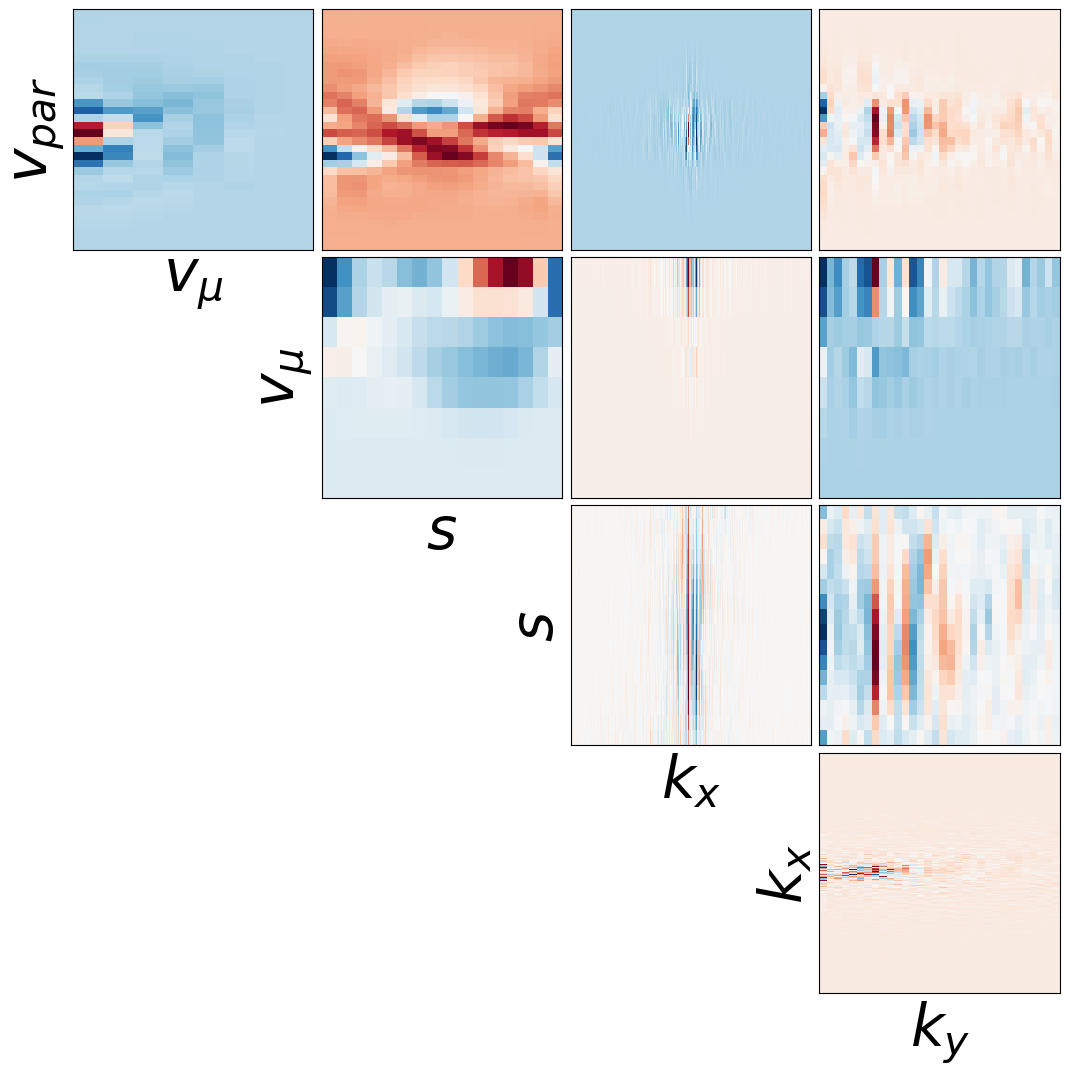

In [25]:
plot4x4(knth)

In [26]:
knth = np.moveaxis(knth, 0, -1).copy()
knth = knth.view(dtype=np.complex64)

In [27]:
knth_zf = knth.copy()
knth_no_zf = knth.copy()
knth_zf[..., 1:, :] = 0.
knth_no_zf[..., 0, :] = 0.
ifft_knth_no_zf = do_ifft(knth_no_zf)
ifft_knth_zf = do_ifft(knth_zf)
orig_ifft = do_ifft(knth.copy())

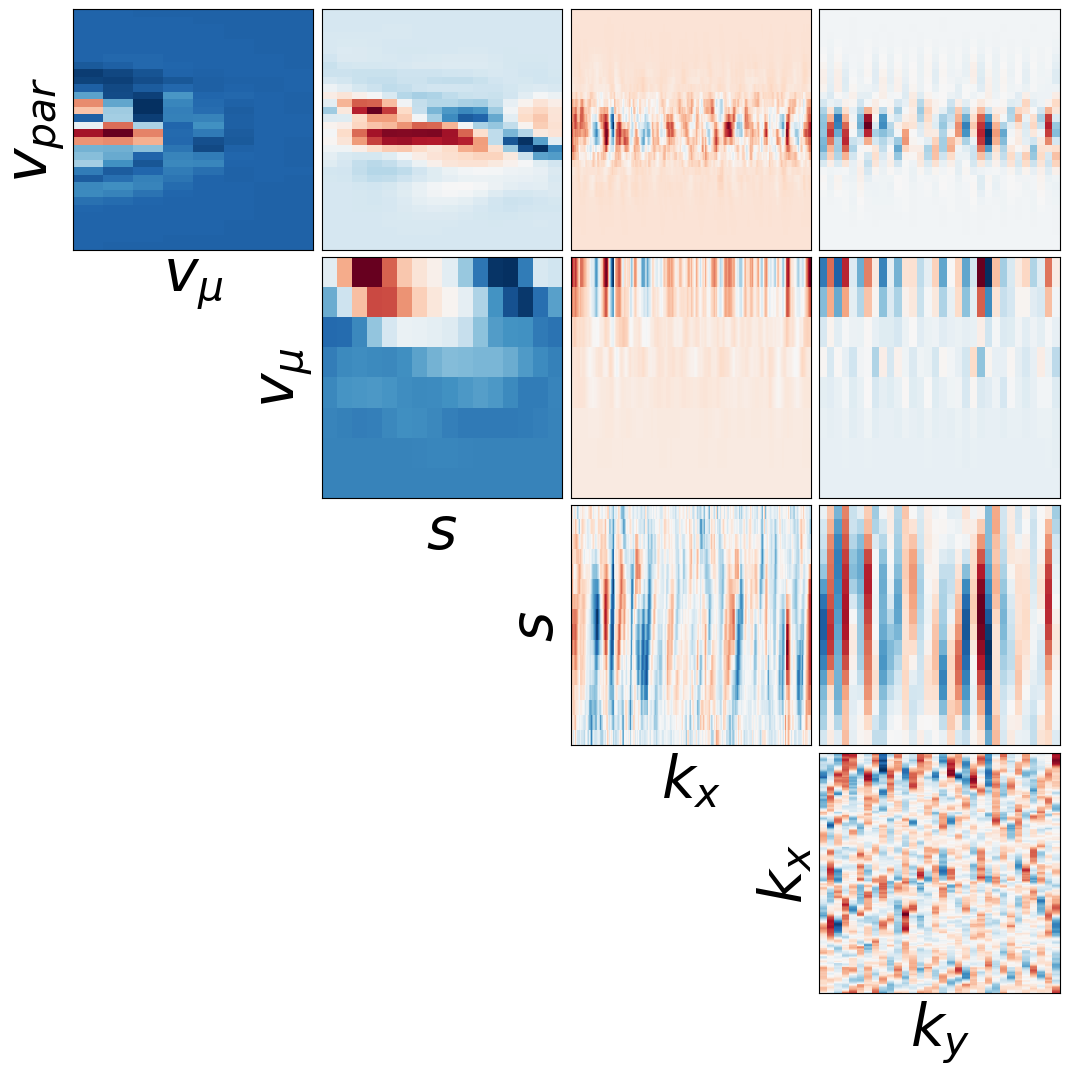

In [19]:
plot4x4(orig_ifft)

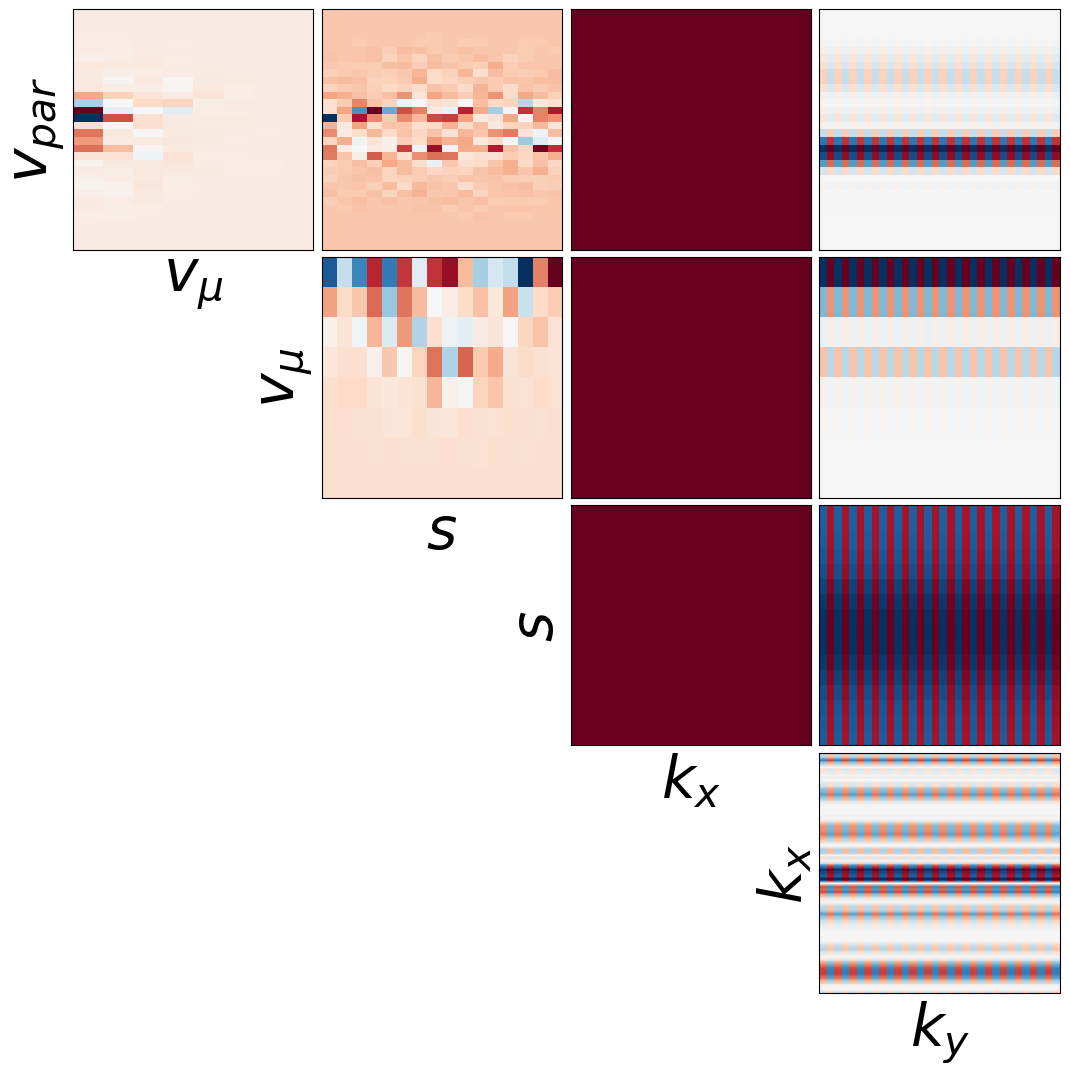

In [20]:
plot4x4(ifft_knth_zf)

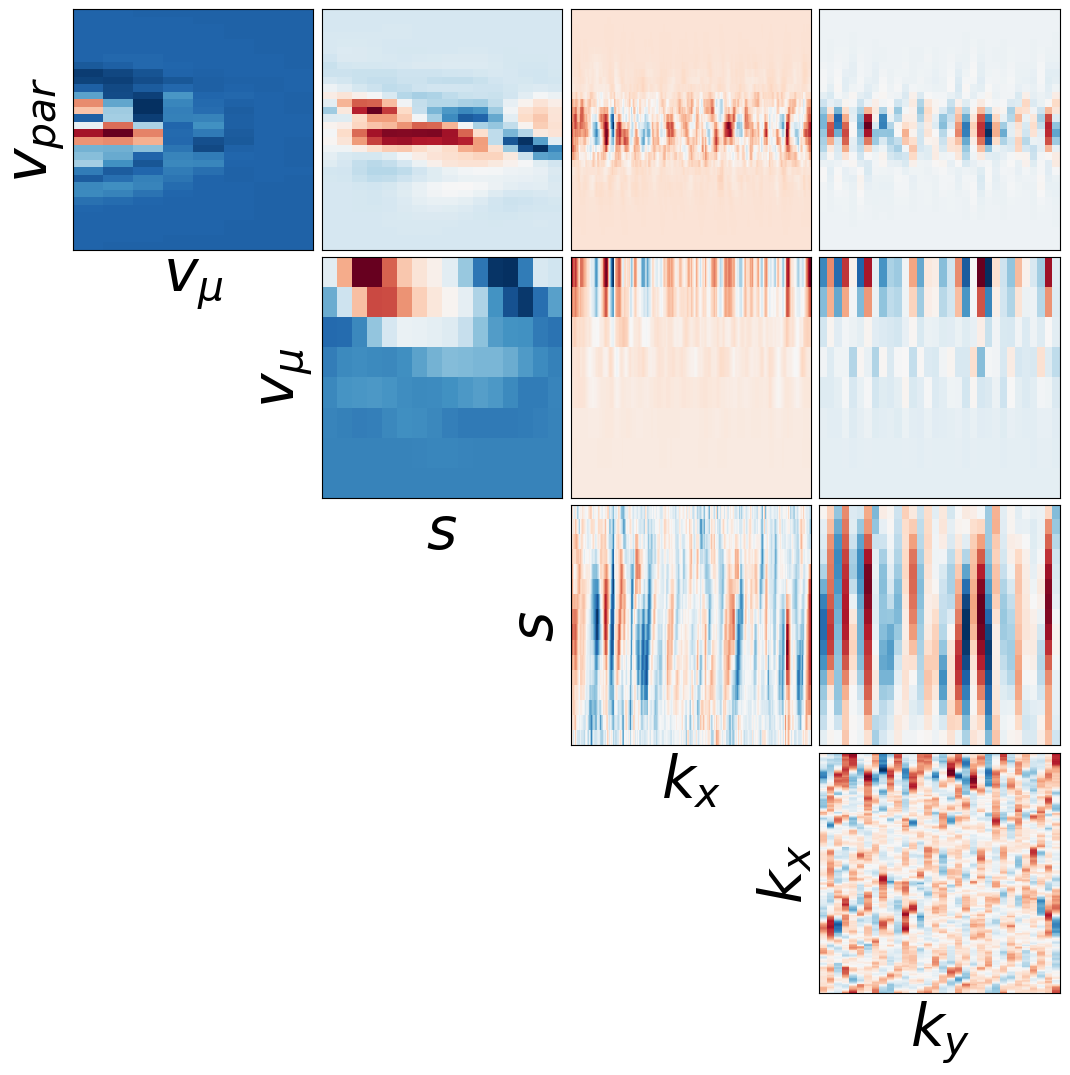

In [21]:
plot4x4(ifft_knth_no_zf)

In [22]:
np.allclose((ifft_knth_no_zf + ifft_knth_zf), orig_ifft)

True

In [94]:
def preprocess(filename, spatial_ifft=False, separate_zf=False):
    assert not (separate_zf and not spatial_ifft), "Need to perform IFFT to maintain shapes for separate_zf"
    dir_in = f"{ROOT}/raw/{filename}"
    dir_out = f"/local00/bioinf/gyrokinetics/preprocessed"
    if not os.path.exists(dir_out):
        os.makedirs(dir_out)

    ks = K_files(dir_in)
    potens, ts_slices = poten_files(dir_in)
    # get timestamps
    ts = []
    for k in ks:
        # load corresponding timestep
        with open(f"{dir_in}/{k}.dat", "r") as file:
            for line in file:
                line_split = line.split("=")
                if line_split[0].strip() == "TIME":
                    time = float(line_split[1].strip().strip(",").strip())
                    ts.append(time)
    timesteps = np.array(ts)

    # read helper vars
    sgrid = np.loadtxt(f"{dir_in}/sgrid")
    xphi = np.loadtxt(f"{dir_in}/xphi")
    krho = np.loadtxt(f"{dir_in}/krho")
    vpgr = np.loadtxt(f"{dir_in}/vpgr.dat")
    # number of parallel direction grid points
    ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]
    # number of x, y grid points (in real space)
    nx, ny = xphi.shape[1], xphi.shape[0]
    # number of modes in x and y direction
    nkx, nky = krho.shape[1], krho.shape[0]
    # get velocity space resolutions
    nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

    resolution = (nvpar, nmu, ns, nkx, nky)

    # load fluxes
    fluxes = np.loadtxt(f"{dir_in}/fluxes.dat")[:, 1]
    print(ks)
    fluxes = fluxes[ts_slices]

    # load parameters
    config = parse_input_dat(f"{dir_in}/input.dat")
    ion_temp_grad = config["SPECIES"]["rlt"]

    # create h5 file with timestamps and field data
    ifft_tag = "_ifft" if spatial_ifft else ""
    zf_tag = "_separate_zf" if separate_zf else ""
    h5_filename = f"{dir_out}/{filename}{ifft_tag}{zf_tag}.h5"

    stats = {"mean": [], "var": [], "min": [], "max": []}

    with h5py.File(h5_filename, "w") as file:

        # group for metadata (e.g. timesteps)
        metadata_group = file.create_group("metadata")
        metadata_group.create_dataset("timesteps", data=timesteps)
        metadata_group.create_dataset("fluxes", data=fluxes)
        metadata_group.create_dataset("resolution", data=resolution)
        metadata_group.create_dataset("ion_temp_grad", data=ion_temp_grad, shape=(1,))

        # group for our 6D field data
        data_group = file.create_group("data")
        for idx, (k, pot) in tqdm(
            enumerate(zip(ks, potens)),
            f"Processing {filename} -> {filename + ifft_tag + zf_tag + '.h5'}",
            total=len(ks),
        ):
            # Load the full distribution function data
            with open(f"{dir_in}/{k}", "rb") as fid:
                ff = np.fromfile(fid, dtype=np.float64)

            # Reshape the distribution function (copy for speeed in stat computation)
            knth = np.reshape(ff, (2, *resolution), order="F").astype("float32").copy()
            if spatial_ifft:
                # invert fft on spatial
                knth = np.moveaxis(knth, 0, -1).copy()
                knth = knth.view(dtype=np.complex64)
                if separate_zf:
                    knth_zf = knth.copy()
                    knth_no_zf = knth.copy()
                    knth_zf[..., 1:, :] = 0.
                    knth_no_zf[..., 0, :] = 0.
                    ifft_knth_no_zf = do_ifft(knth_no_zf)
                    ifft_knth_zf = do_ifft(knth_zf)
                    knth = np.concatenate([ifft_knth_no_zf, ifft_knth_zf], axis=0)
                else:     
                    knth = do_ifft(knth)

            # update running averages
            stats["mean"].append(np.mean(knth, (1, 2, 3, 4, 5)))
            stats["var"].append(np.var(knth, (1, 2, 3, 4, 5)))
            stats["min"].append(np.min(knth, (1, 2, 3, 4, 5)))
            stats["max"].append(np.max(knth, (1, 2, 3, 4, 5)))

            # Add the reshaped data as a dataset to the "data" group
            k_name = "timestep_" + str(idx).zfill(5)
            data_group.create_dataset(k_name, data=knth)

            # load the potential field
            a = np.loadtxt(f"{dir_in}/{pot}")
            phi = np.reshape(a, (nx, ns, ny), order="F").astype("float32").copy()
            poten_name = "poten_" + str(idx).zfill(5)
            data_group.create_dataset(poten_name, data=phi)

        stats = {k: np.stack(v) for k, v in stats.items()}
        metadata_group.create_dataset("k_mean", data=stats["mean"].mean(0))
        metadata_group.create_dataset("k_std", data=np.sqrt(stats["var"].mean(0)))
        metadata_group.create_dataset("k_min", data=stats["min"].mean(0))
        metadata_group.create_dataset("k_max", data=stats["max"].mean(0))

        return h5_filename

In [95]:
IFFT = True
separate_zf = True
datasets = [
    "cyclone6_2",
    "cyclone7_2",
    "cyclone8_2",
    "cyclone9_2",
    "cyclone10_2",
    "cyclone11_2",
    "cyclone12_2",
]

for f in datasets:
    h5_filename = preprocess(f, spatial_ifft=IFFT, separate_zf=separate_zf)
    # set rwx permissions
    try:
        os.chmod(h5_filename, 0o777)
    except PermissionError:
        pass
    # read in the structure and example field of the created h5 file
    with h5py.File(h5_filename, "r") as h5f:
        # Read the 'metadata/timesteps' dataset
        timesteps = len(h5f["data"])
        rlt = h5f["metadata/ion_temp_grad"][:]
        rlt = h5f["metadata/ion_temp_grad"][:]
        timestep_0 = h5f["data/timestep_00000"][:]
        mean, std = h5f["metadata/k_mean"][0], h5f["metadata/k_std"][0]
        min_, max_ = h5f["metadata/k_min"][0], h5f["metadata/k_max"][0]
        print(
            f"{h5_filename}:\n "
            f"\tpoints: {timesteps}, shape of timestep_00000: {timestep_0.shape}\n"
            f"\trange: ({min_:.3E}, {max_:.3E}), mean:{mean:.3E}, std:{std:.3E} \n"
            f"\trlt: {rlt}\n"
        )

['K01', 'K02', 'K03', 'K04', 'K05', 'K06', 'K07', 'K08', 'K09', 'K10', 'K11', 'K12', 'K13', 'K14', 'K15', 'K16', 'K17', 'K18', 'K19', 'K20', 'K21', 'K22', 'K23', 'K24', 'K25', 'K26', 'K27', 'K28', 'K29', 'K30', 'K31', 'K32', 'K33', 'K34', 'K35', 'K36', 'K37', 'K38', 'K39', 'K40', 'K41', 'K42', 'K43', 'K44', 'K45', 'K46', 'K47', 'K48', 'K49', 'K50', 'K51', 'K52', 'K53', 'K54', 'K55', 'K56', 'K57', 'K58', 'K59', 'K60', 'K61', 'K62', 'K63', 'K64', 'K65', 'K66', 'K67', 'K68', 'K69', 'K70', 'K71', 'K72', 'K73', 'K74', 'K75', 'K76', 'K77', 'K78', 'K79', 'K80', 'K81', 'K82', 'K83', 'K84', 'K85', 'K86', 'K87', 'K88', 'K89', 'K90', 'K91', 'K92', 'K93', 'K94', 'K95', 'K96', 'K97', 'K98', 'K99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143'

Processing cyclone4_2_2 -> cyclone4_2_2_ifft_separate_zf.h5: 100%|█| 166/166 [18:43<00:00,  6.77s/it]


/local00/bioinf/gyrokinetics/preprocessed/cyclone4_2_2_ifft_separate_zf.h5:
 	points: 332, shape of timestep_00000: (4, 32, 8, 16, 255, 32)
	range: (-3.034E-03, 3.034E-03), mean:-4.335E-09, std:8.940E-05 
	rlt: [6.9]

['K01', 'K02', 'K03', 'K04', 'K05', 'K06', 'K07', 'K08', 'K09', 'K10', 'K11', 'K12', 'K13', 'K14', 'K15', 'K16', 'K17', 'K18', 'K19', 'K20', 'K21', 'K22', 'K23', 'K24', 'K25', 'K26', 'K27', 'K28', 'K29', 'K30', 'K31', 'K32', 'K33', 'K34', 'K35', 'K36', 'K37', 'K38', 'K39', 'K40', 'K41', 'K42', 'K43', 'K44', 'K45', 'K46', 'K47', 'K48', 'K49', 'K50', 'K51', 'K52', 'K53', 'K54', 'K55', 'K56', 'K57', 'K58', 'K59', 'K60', 'K61', 'K62', 'K63', 'K64', 'K65', 'K66', 'K67', 'K68', 'K69', 'K70', 'K71', 'K72', 'K73', 'K74', 'K75', 'K76', 'K77', 'K78', 'K79', 'K80', 'K81', 'K82', 'K83', 'K84', 'K85', 'K86', 'K87', 'K88', 'K89', 'K90', 'K91', 'K92', 'K93', 'K94', 'K95', 'K96', 'K97', 'K98', 'K99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112

Processing cyclone5_2 -> cyclone5_2_ifft_separate_zf.h5: 100%|█████| 166/166 [21:08<00:00,  7.64s/it]


/local00/bioinf/gyrokinetics/preprocessed/cyclone5_2_ifft_separate_zf.h5:
 	points: 332, shape of timestep_00000: (4, 32, 8, 16, 255, 32)
	range: (-1.449E-03, 1.455E-03), mean:-1.984E-09, std:4.802E-05 
	rlt: [4.9]

['K01', 'K02', 'K03', 'K04', 'K05', 'K06', 'K07', 'K08', 'K09', 'K10', 'K11', 'K12', 'K13', 'K14', 'K15', 'K16', 'K17', 'K18', 'K19', 'K20', 'K21', 'K22', 'K23', 'K24', 'K25', 'K26', 'K27', 'K28', 'K29', 'K30', 'K31', 'K32', 'K33', 'K34', 'K35', 'K36', 'K37', 'K38', 'K39', 'K40', 'K41', 'K42', 'K43', 'K44', 'K45', 'K46', 'K47', 'K48', 'K49', 'K50', 'K51', 'K52', 'K53', 'K54', 'K55', 'K56', 'K57', 'K58', 'K59', 'K60', 'K61', 'K62', 'K63', 'K64', 'K65', 'K66', 'K67', 'K68', 'K69', 'K70', 'K71', 'K72', 'K73', 'K74', 'K75', 'K76', 'K77', 'K78', 'K79', 'K80', 'K81', 'K82', 'K83', 'K84', 'K85', 'K86', 'K87', 'K88', 'K89', 'K90', 'K91', 'K92', 'K93', 'K94', 'K95', 'K96', 'K97', 'K98', 'K99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112',

Processing cyclone6_2 -> cyclone6_2_ifft_separate_zf.h5:  69%|███▍ | 114/166 [12:46<05:49,  6.73s/it]


KeyboardInterrupt: 

In [ ]:
IFFT = True
datasets = [
    "cyclone18_2",
    "cyclone19_2",
    "cyclone20_2",
    "cyclone21_2",
]

for f in datasets:
    h5_filename = preprocess(f, spatial_ifft=IFFT)
    # set rwx permissions
    try:
        os.chmod(h5_filename, 0o777)
    except PermissionError:
        pass
    # read in the structure and example field of the created h5 file
    with h5py.File(h5_filename, "r") as h5f:
        # Read the 'metadata/timesteps' dataset
        timesteps = len(h5f["data"])
        rlt = h5f["metadata/ion_temp_grad"][:]
        rlt = h5f["metadata/ion_temp_grad"][:]
        timestep_0 = h5f["data/timestep_00000"][:]
        mean, std = h5f["metadata/k_mean"][0], h5f["metadata/k_std"][0]
        min_, max_ = h5f["metadata/k_min"][0], h5f["metadata/k_max"][0]
        print(
            f"{h5_filename}:\n "
            f"\tpoints: {timesteps}, shape of timestep_00000: {timestep_0.shape}\n"
            f"\trange: ({min_:.3E}, {max_:.3E}), mean:{mean:.3E}, std:{std:.3E} \n"
            f"\trlt: {rlt}\n"
        )